## CLASSIFYING MOVIE REVIEWS: A BINARY CLASSIFICATION EXAMPLE ##

Dataset

In [13]:
import random
import numpy as np
import tensorflow as tf
import os

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [14]:
#Loading the IMDB dataset

from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

In [3]:
#Simple check
print(train_data[0]) # First review (Encoded to int tensor)
print(train_labels[0]) # Label (1 - positive, 0 - negative)
max([max(sequence) for sequence in train_data])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
1


9999

In [4]:
#Decoding reviews back to text
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, '?') for i in train_data[0]]
)

In [5]:
decoded_review[:9999] # ? indicate the start of sequence

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

Preparing the data

In [6]:
#encoding the integer sequences via multi-hot encoding

import numpy as np

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results

x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes = 10000)


x_train[0]

array([0., 1., 1., ..., 0., 0., 0.], shape=(10000,))

In [15]:
y_train = train_labels.astype('float32')
y_test = test_labels.astype('float32')

Model building

In [3]:
#Model definition
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(16, activation = 'relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation = 'sigmoid')
    ]
)

In [9]:
# Compiling the model
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics=['accuracy'],
)

Approach validation

In [16]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [11]:
# Training the model

history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs = 20,
    batch_size = 512,
    validation_data = (x_val, y_val)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7714 - loss: 0.5455 - val_accuracy: 0.8586 - val_loss: 0.3884
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9041 - loss: 0.2871 - val_accuracy: 0.8802 - val_loss: 0.3015
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9370 - loss: 0.1949 - val_accuracy: 0.8868 - val_loss: 0.2824
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9553 - loss: 0.1460 - val_accuracy: 0.8865 - val_loss: 0.2839
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9702 - loss: 0.1119 - val_accuracy: 0.8837 - val_loss: 0.2971
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9784 - loss: 0.0891 - val_accuracy: 0.8765 - val_loss: 0.3311
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9848 - loss: 0.0714 - val_accuracy: 0.8788 - val_loss: 0.3446
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9898 - loss: 0.0557 - val_accuracy: 0.8785 - v

In [12]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

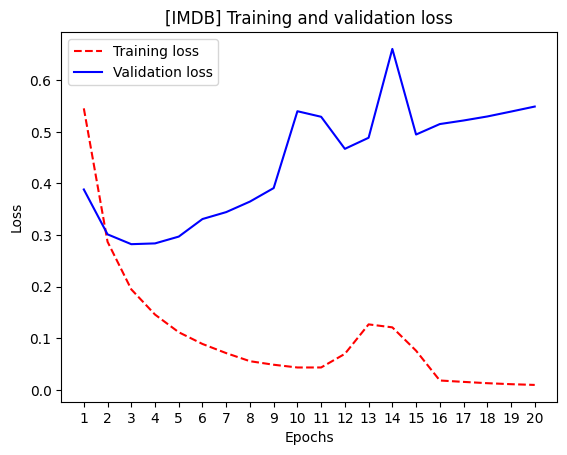

In [13]:
#Plotting the training and validation loss

import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'r--', label = 'Training loss')
plt.plot(epochs, val_loss_values, 'b', label = 'Validation loss')
plt.title('[IMDB] Training and validation loss')
plt.xlabel('Epochs')
plt.xticks(epochs)
plt.ylabel('Loss')
plt.legend()
plt.show()


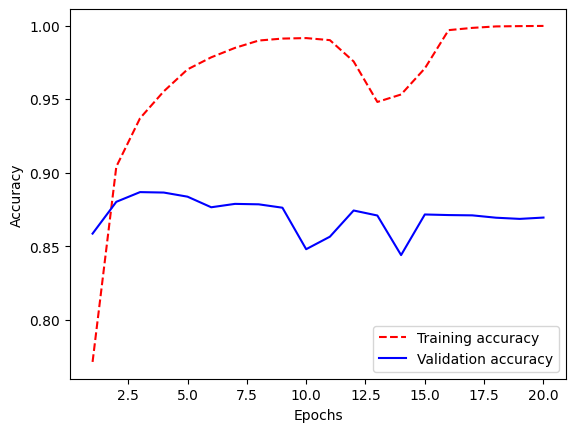

In [14]:
#Plotting the training and validation accuracy

plt.clf()
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
plt.plot(epochs, acc, 'r--', label = 'Training accuracy')
plt.plot(epochs, val_acc, 'b', label = 'Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Predict and see the magic!

In [15]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test accuracy: {accuracy:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8579 - loss: 0.5974
Test accuracy: 0.8579


```The result is quite okay, but there's still rooms for improvement!```

In [16]:
#Dropout, less epochs to avoid overfitting

model2 = keras.Sequential([
    layers.Dense(16, activation='gelu'),
    layers.Dropout(0.5),
    layers.Dense(16, activation='gelu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [17]:
model2.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics=['accuracy'],
)

In [18]:
history = model2.fit(
    partial_x_train,
    partial_y_train,
    epochs = 10,
    batch_size = 512,
    validation_data = (x_val, y_val)
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6522 - loss: 0.6407 - val_accuracy: 0.8319 - val_loss: 0.5476
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7869 - loss: 0.5149 - val_accuracy: 0.8624 - val_loss: 0.4236
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8545 - loss: 0.4142 - val_accuracy: 0.8793 - val_loss: 0.3436
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8871 - loss: 0.3403 - val_accuracy: 0.8844 - val_loss: 0.3022
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9085 - loss: 0.2862 - val_accuracy: 0.8878 - val_loss: 0.2856
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9231 - loss: 0.2430 - val_accuracy: 0.8890 - val_loss: 0.2845
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9371 - loss: 0.2104 - val_accuracy: 0.8868 - val_loss: 0.2828
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9463 - loss: 0.1802 - val_accuracy: 0.8875 - v

In [19]:
loss, accuracy = model2.evaluate(x_test, y_test)
print(f'Test accuracy: {accuracy:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8767 - loss: 0.3400
Test accuracy: 0.8767


```We can take another approach!```

In [17]:
from keras.preprocessing.sequence import pad_sequences

maxlen = 256

x_train = pad_sequences(train_data, maxlen=maxlen)
x_test = pad_sequences(test_data, maxlen=maxlen)

x_val = x_train[:10000]
partial_x_train = x_train[10000:]

In [18]:
model3 = keras.Sequential([
    layers.Embedding(10000, 32),
    layers.Conv1D(32, 3, activation='relu'),
    layers.GlobalMaxPooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])    

In [19]:
model3.compile(
    optimizer='adamw',
    loss = 'mean_squared_error',
    metrics= ['accuracy']
)

In [20]:
history = model3.fit(
    partial_x_train,
    partial_y_train,
    epochs = 15,
    batch_size = 512,
    validation_data = (x_val, y_val)
)

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6115 - loss: 0.2439 - val_accuracy: 0.6886 - val_loss: 0.2305
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7091 - loss: 0.2113 - val_accuracy: 0.7616 - val_loss: 0.1879
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7799 - loss: 0.1704 - val_accuracy: 0.8004 - val_loss: 0.1499
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8287 - loss: 0.1351 - val_accuracy: 0.8270 - val_loss: 0.1271
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8592 - loss: 0.1091 - val_accuracy: 0.8431 - val_loss: 0.1149
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8915 - loss: 0.0886 - val_accuracy: 0.8551 - val_loss: 0.1061
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9234 - loss: 0.0684 - val_accuracy: 0.8635 - val_loss: 0.1004
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9470 - loss: 0.0518 - val_accuracy: 0.8662 - v

In [21]:
loss, accuracy = model3.evaluate(x_test, y_test)
print(f'Test accuracy: {accuracy:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8617 - loss: 0.1020
Test accuracy: 0.8617
